In [1]:
# Chunk 1: I load the dataset and set up the working environment

from google.colab import files
import os
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, IsolationForest

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

# I keep plots readable for the report
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

print("Please upload your creditcard.csv dataset file.")
uploaded = files.upload()

file_name = list(uploaded.keys())[0]
print(f"\nUploaded file: {file_name}")

df = pd.read_csv(file_name)

print("\nDataset loaded successfully.")
print("Shape:", df.shape)

display(df.head())
display(df.tail())

Please upload your creditcard.csv dataset file.


Saving creditcard.csv to creditcard.csv

Uploaded file: creditcard.csv

Dataset loaded successfully.
Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


In [2]:
# Chunk 2: I check the dataset structure and the fraud class balance

print("Dataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("Data Type"))

missing_summary = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df) * 100).round(4)
})

print("\nMissing value summary:")
display(missing_summary)

duplicate_count = df.duplicated().sum()
duplicate_percentage = (duplicate_count / len(df)) * 100

print("\nDuplicate rows:")
print(f"Duplicate count: {duplicate_count}")
print(f"Duplicate percentage: {duplicate_percentage:.4f}%")

class_counts = df["Class"].value_counts().sort_index()
class_percentages = (df["Class"].value_counts(normalize=True).sort_index() * 100).round(4)

class_summary = pd.DataFrame({
    "Class Label": ["Legitimate transaction", "Fraudulent transaction"],
    "Class Value": [0, 1],
    "Transaction Count": class_counts.values,
    "Percentage": class_percentages.values
})

print("\nTarget variable distribution:")
display(class_summary)

dataset_overview = pd.DataFrame({
    "Item": [
        "Total rows",
        "Total columns",
        "Target variable",
        "Legitimate transactions",
        "Fraudulent transactions",
        "Fraud percentage",
        "Missing values",
        "Duplicate rows"
    ],
    "Value": [
        df.shape[0],
        df.shape[1],
        "Class",
        int(class_counts.loc[0]),
        int(class_counts.loc[1]),
        f"{class_percentages.loc[1]}%",
        int(df.isnull().sum().sum()),
        int(duplicate_count)
    ]
})

print("\nDataset overview table:")
display(dataset_overview)

Dataset shape:
(284807, 31)

Column names:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Data types:


,Data Type
Time,float64
V1,float64
V2,float64
V3,float64
V4,float64
V5,float64
V6,float64
V7,float64
V8,float64
V9,float64



Missing value summary:


,Missing Values,Missing Percentage
Time,0,0.0
V1,0,0.0
V2,0,0.0
V3,0,0.0
V4,0,0.0
V5,0,0.0
V6,0,0.0
V7,0,0.0
V8,0,0.0
V9,0,0.0



Duplicate rows:
Duplicate count: 1081
Duplicate percentage: 0.3796%

Target variable distribution:


,Class Label,Class Value,Transaction Count,Percentage
0,Legitimate transaction,0,284315,99.8273
1,Fraudulent transaction,1,492,0.1727



Dataset overview table:


,Item,Value
0,Total rows,284807
1,Total columns,31
2,Target variable,Class
3,Legitimate transactions,284315
4,Fraudulent transactions,492
5,Fraud percentage,0.1727%
6,Missing values,0
7,Duplicate rows,1081


In [3]:
# Chunk 3: I remove duplicate rows and confirm the cleaned dataset

df_clean = df.drop_duplicates().copy()

print("Original dataset shape:")
print(df.shape)

print("\nCleaned dataset shape after duplicate removal:")
print(df_clean.shape)

removed_rows = df.shape[0] - df_clean.shape[0]
removed_percentage = (removed_rows / df.shape[0]) * 100

print("\nRows removed:")
print(f"{removed_rows} rows removed")
print(f"{removed_percentage:.4f}% of the original dataset removed")

clean_class_counts = df_clean["Class"].value_counts().sort_index()
clean_class_percentages = (df_clean["Class"].value_counts(normalize=True).sort_index() * 100).round(4)

clean_class_summary = pd.DataFrame({
    "Class Label": ["Legitimate transaction", "Fraudulent transaction"],
    "Class Value": [0, 1],
    "Transaction Count": clean_class_counts.values,
    "Percentage": clean_class_percentages.values
})

print("\nCleaned target variable distribution:")
display(clean_class_summary)

clean_dataset_overview = pd.DataFrame({
    "Item": [
        "Original rows",
        "Original columns",
        "Rows after duplicate removal",
        "Columns after duplicate removal",
        "Rows removed",
        "Missing values after cleaning",
        "Legitimate transactions after cleaning",
        "Fraudulent transactions after cleaning",
        "Fraud percentage after cleaning"
    ],
    "Value": [
        df.shape[0],
        df.shape[1],
        df_clean.shape[0],
        df_clean.shape[1],
        removed_rows,
        int(df_clean.isnull().sum().sum()),
        int(clean_class_counts.loc[0]),
        int(clean_class_counts.loc[1]),
        f"{clean_class_percentages.loc[1]}%"
    ]
})

print("\nCleaned dataset overview table:")
display(clean_dataset_overview)

Original dataset shape:
(284807, 31)

Cleaned dataset shape after duplicate removal:
(283726, 31)

Rows removed:
1081 rows removed
0.3796% of the original dataset removed

Cleaned target variable distribution:


,Class Label,Class Value,Transaction Count,Percentage
0,Legitimate transaction,0,283253,99.8333
1,Fraudulent transaction,1,473,0.1667



Cleaned dataset overview table:


,Item,Value
0,Original rows,284807
1,Original columns,31
2,Rows after duplicate removal,283726
3,Columns after duplicate removal,31
4,Rows removed,1081
5,Missing values after cleaning,0
6,Legitimate transactions after cleaning,283253
7,Fraudulent transactions after cleaning,473
8,Fraud percentage after cleaning,0.1667%


Output folder created: fraud_detection_outputs

Descriptive statistics with skewness and kurtosis:


,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
Time,283726.0,94811.077600,47481.047891,0.000000,54204.750000,84692.500000,139298.000000,172792.000000,-0.035581,-1.293432
V1,283726.0,0.005917,1.948026,-56.407510,-0.915951,0.020384,1.316068,2.454930,-3.273271,32.727332
V2,283726.0,-0.004135,1.646703,-72.715728,-0.600321,0.063949,0.800283,22.057729,-4.695162,96.898173
V3,283726.0,0.001613,1.508682,-48.325589,-0.889682,0.179963,1.026960,9.382558,-2.151984,25.186530
V4,283726.0,-0.002966,1.414184,-5.683171,-0.850134,-0.022248,0.739647,16.875344,0.671504,2.618780
V5,283726.0,0.001828,1.377008,-113.743307,-0.689830,-0.053468,0.612218,34.801666,-2.414079,209.277467
V6,283726.0,-0.001139,1.331931,-26.160506,-0.769031,-0.275168,0.396792,73.301626,1.829880,42.838886
V7,283726.0,0.001801,1.227664,-43.557242,-0.552509,0.040859,0.570474,120.589494,2.890271,414.142188
V8,283726.0,-0.000854,1.179054,-73.216718,-0.208828,0.021898,0.325704,20.007208,-8.310970,215.016933
V9,283726.0,-0.001596,1.095492,-13.434066,-0.644221,-0.052596,0.595977,15.594995,0.537663,3.516661


,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
Time,283726.0,94811.077600,47481.047891,0.0,54204.75,84692.5,139298.00,172792.00,-0.035581,-1.293432
Amount,283726.0,88.472687,250.399437,0.0,5.60,22.0,77.51,25691.16,16.978803,844.471319
Class,283726.0,0.001667,0.040796,0.0,0.00,0.0,0.00,1.00,24.430545,594.855726



Class distribution table:


,Class,Class Value,Count,Percentage
0,Legitimate,0,283253,99.8333
1,Fraud,1,473,0.1667


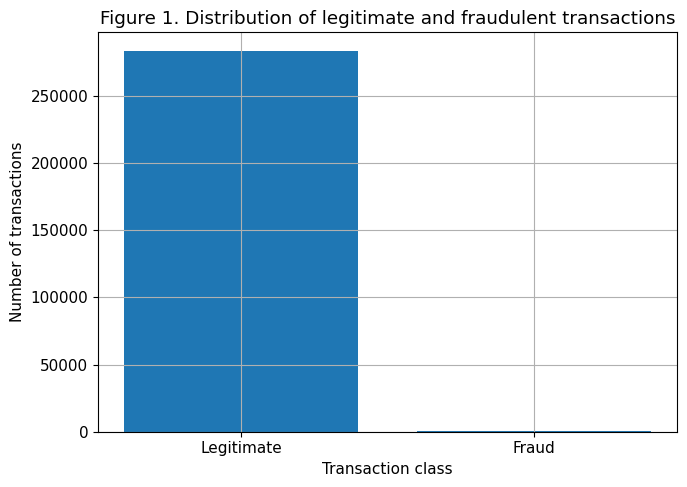

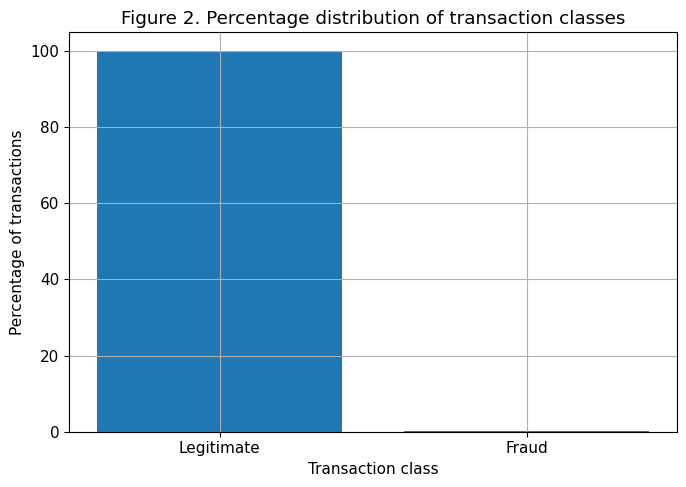


Saved files:
- table_1_cleaned_dataset_overview.csv
- table_2_class_distribution.csv
- table_3_descriptive_statistics.csv
- figure_1_class_distribution.png
- figure_2_class_percentage.png


In [4]:
# Chunk 4: I create the first EDA tables and figures for the report

import os

output_folder = "fraud_detection_outputs"
os.makedirs(output_folder, exist_ok=True)

print("Output folder created:", output_folder)

# Main descriptive statistics
descriptive_stats = df_clean.describe().T
descriptive_stats["skewness"] = df_clean.skew(numeric_only=True)
descriptive_stats["kurtosis"] = df_clean.kurtosis(numeric_only=True)

print("\nDescriptive statistics with skewness and kurtosis:")
display(descriptive_stats.head(10))
display(descriptive_stats.loc[["Time", "Amount", "Class"]])

# Class distribution table
class_distribution = df_clean["Class"].value_counts().sort_index()
class_distribution_percent = df_clean["Class"].value_counts(normalize=True).sort_index() * 100

class_distribution_table = pd.DataFrame({
    "Class": ["Legitimate", "Fraud"],
    "Class Value": [0, 1],
    "Count": class_distribution.values,
    "Percentage": class_distribution_percent.round(4).values
})

print("\nClass distribution table:")
display(class_distribution_table)

# Figure 1: Class distribution count
plt.figure(figsize=(7, 5))
plt.bar(["Legitimate", "Fraud"], class_distribution.values)
plt.title("Figure 1. Distribution of legitimate and fraudulent transactions")
plt.xlabel("Transaction class")
plt.ylabel("Number of transactions")
plt.ticklabel_format(style="plain", axis="y")
plt.tight_layout()
plt.savefig(f"{output_folder}/figure_1_class_distribution.png", dpi=300)
plt.show()

# Figure 2: Class distribution percentage
plt.figure(figsize=(7, 5))
plt.bar(["Legitimate", "Fraud"], class_distribution_percent.values)
plt.title("Figure 2. Percentage distribution of transaction classes")
plt.xlabel("Transaction class")
plt.ylabel("Percentage of transactions")
plt.tight_layout()
plt.savefig(f"{output_folder}/figure_2_class_percentage.png", dpi=300)
plt.show()

# Save report tables
clean_dataset_overview.to_csv(f"{output_folder}/table_1_cleaned_dataset_overview.csv", index=False)
class_distribution_table.to_csv(f"{output_folder}/table_2_class_distribution.csv", index=False)
descriptive_stats.to_csv(f"{output_folder}/table_3_descriptive_statistics.csv")

print("\nSaved files:")
print("- table_1_cleaned_dataset_overview.csv")
print("- table_2_class_distribution.csv")
print("- table_3_descriptive_statistics.csv")
print("- figure_1_class_distribution.png")
print("- figure_2_class_percentage.png")

Legitimate transactions: 283253
Fraudulent transactions: 473

Transaction amount summary by class:


,count,mean,std,min,25%,50%,75%,max
Legitimate,283253.0,88.414,250.379,0.0,5.67,22.00,77.46,25691.16
Fraud,473.0,123.872,260.211,0.0,1.00,9.82,105.89,2125.87



Transaction time summary by class:


,count,mean,std,min,25%,50%,75%,max
Legitimate,283253.0,94835.058,47475.551,0.0,54233.0,84711.0,139308.0,172792.0
Fraud,473.0,80450.514,48636.180,406.0,41203.0,73408.0,129095.0,170348.0


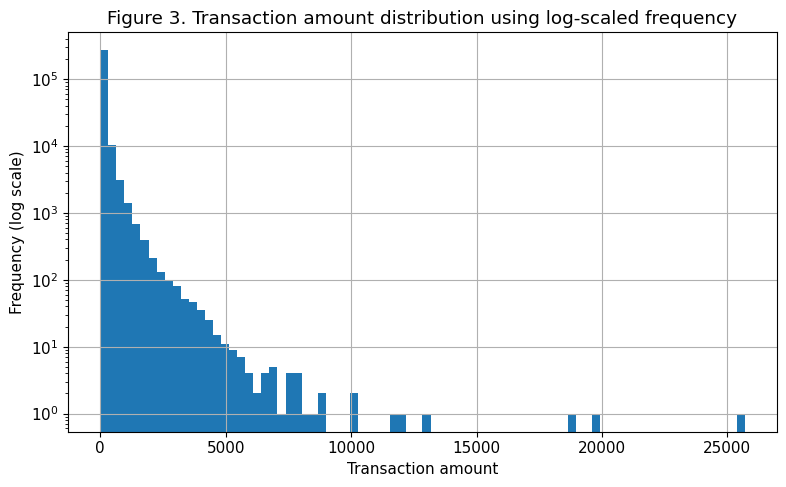

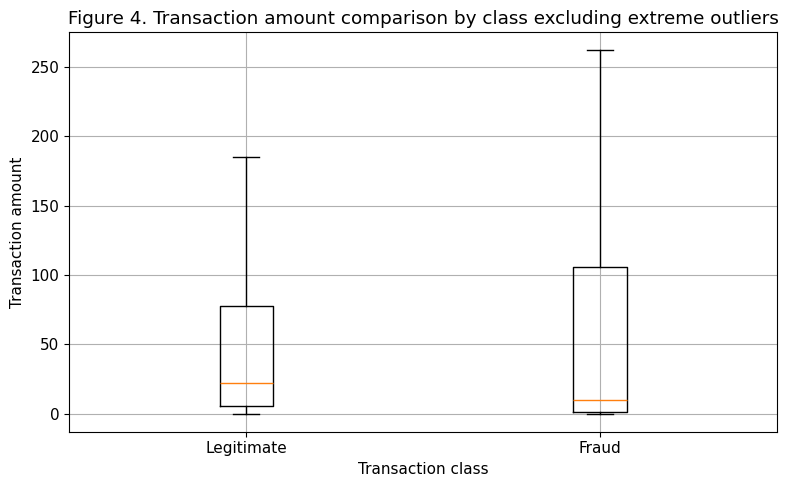

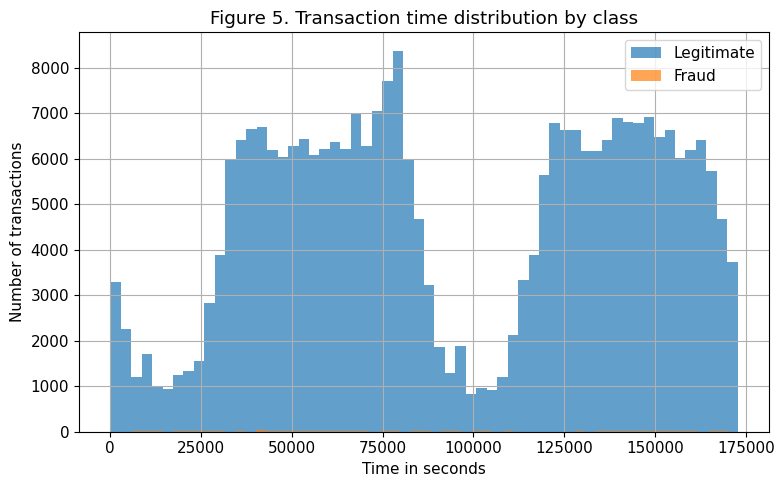

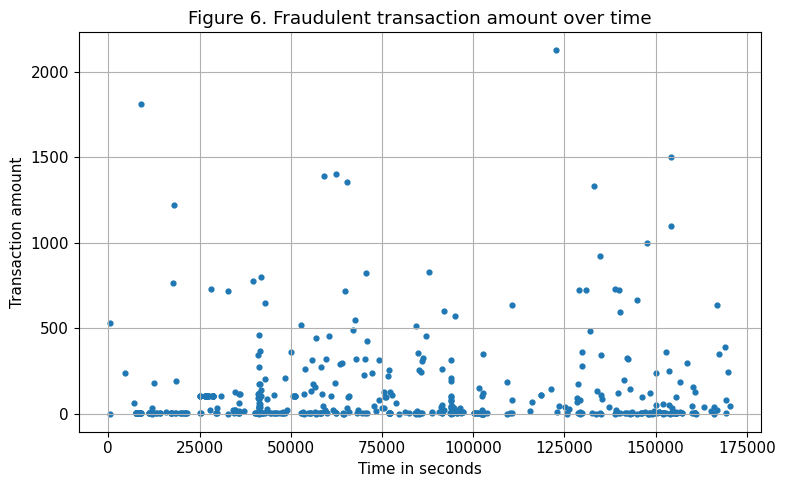


Saved files:
- table_4_amount_summary_by_class.csv
- table_5_time_summary_by_class.csv
- figure_3_amount_distribution_log_frequency.png
- figure_4_amount_boxplot_by_class.png
- figure_5_time_distribution_by_class.png
- figure_6_fraud_amount_over_time.png


In [5]:
# Chunk 5: I explore transaction amount and time patterns

# Separate legitimate and fraud transactions for clearer comparisons
legit = df_clean[df_clean["Class"] == 0]
fraud = df_clean[df_clean["Class"] == 1]

print("Legitimate transactions:", legit.shape[0])
print("Fraudulent transactions:", fraud.shape[0])

amount_summary_by_class = df_clean.groupby("Class")["Amount"].describe().round(3)
amount_summary_by_class.index = ["Legitimate", "Fraud"]

print("\nTransaction amount summary by class:")
display(amount_summary_by_class)

time_summary_by_class = df_clean.groupby("Class")["Time"].describe().round(3)
time_summary_by_class.index = ["Legitimate", "Fraud"]

print("\nTransaction time summary by class:")
display(time_summary_by_class)

# Figure 3: Amount distribution with log scale
plt.figure(figsize=(8, 5))
plt.hist(df_clean["Amount"], bins=80)
plt.yscale("log")
plt.title("Figure 3. Transaction amount distribution using log-scaled frequency")
plt.xlabel("Transaction amount")
plt.ylabel("Frequency (log scale)")
plt.tight_layout()
plt.savefig(f"{output_folder}/figure_3_amount_distribution_log_frequency.png", dpi=300)
plt.show()

# Figure 4: Amount comparison by class using boxplot
plt.figure(figsize=(8, 5))
plt.boxplot(
    [legit["Amount"], fraud["Amount"]],
    labels=["Legitimate", "Fraud"],
    showfliers=False
)
plt.title("Figure 4. Transaction amount comparison by class excluding extreme outliers")
plt.xlabel("Transaction class")
plt.ylabel("Transaction amount")
plt.tight_layout()
plt.savefig(f"{output_folder}/figure_4_amount_boxplot_by_class.png", dpi=300)
plt.show()

# Figure 5: Transaction time distribution by class
plt.figure(figsize=(8, 5))
plt.hist(legit["Time"], bins=60, alpha=0.7, label="Legitimate")
plt.hist(fraud["Time"], bins=60, alpha=0.7, label="Fraud")
plt.title("Figure 5. Transaction time distribution by class")
plt.xlabel("Time in seconds")
plt.ylabel("Number of transactions")
plt.legend()
plt.tight_layout()
plt.savefig(f"{output_folder}/figure_5_time_distribution_by_class.png", dpi=300)
plt.show()

# Figure 6: Fraud transactions over time
plt.figure(figsize=(8, 5))
plt.scatter(fraud["Time"], fraud["Amount"], s=12)
plt.title("Figure 6. Fraudulent transaction amount over time")
plt.xlabel("Time in seconds")
plt.ylabel("Transaction amount")
plt.tight_layout()
plt.savefig(f"{output_folder}/figure_6_fraud_amount_over_time.png", dpi=300)
plt.show()

# Save EDA summary tables
amount_summary_by_class.to_csv(f"{output_folder}/table_4_amount_summary_by_class.csv")
time_summary_by_class.to_csv(f"{output_folder}/table_5_time_summary_by_class.csv")

print("\nSaved files:")
print("- table_4_amount_summary_by_class.csv")
print("- table_5_time_summary_by_class.csv")
print("- figure_3_amount_distribution_log_frequency.png")
print("- figure_4_amount_boxplot_by_class.png")
print("- figure_5_time_distribution_by_class.png")
print("- figure_6_fraud_amount_over_time.png")

Top 15 features most correlated with fraud class:


,Correlation with Class
V17,-0.313498
V14,-0.293375
V12,-0.250711
V10,-0.206971
V16,-0.187186
V3,-0.182322
V7,-0.172347
V11,0.149067
V4,0.129326
V18,-0.105340



Bottom 10 features least correlated with fraud class:


,Correlation with Class
Time,-0.012359
V28,0.009682
V24,-0.007210
V23,-0.006333
Amount,0.005777
V22,0.004887
V26,0.004265
V13,-0.003897
V15,-0.003300
V25,0.003202


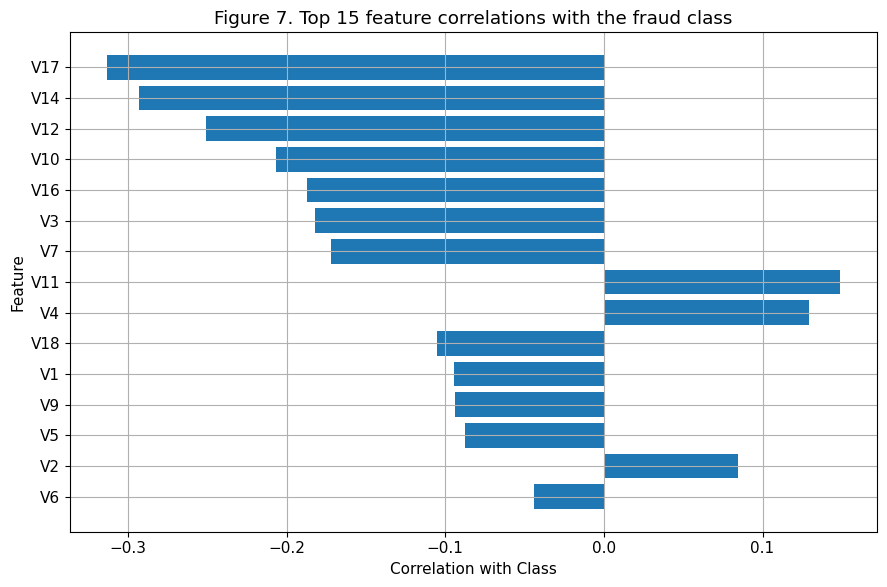

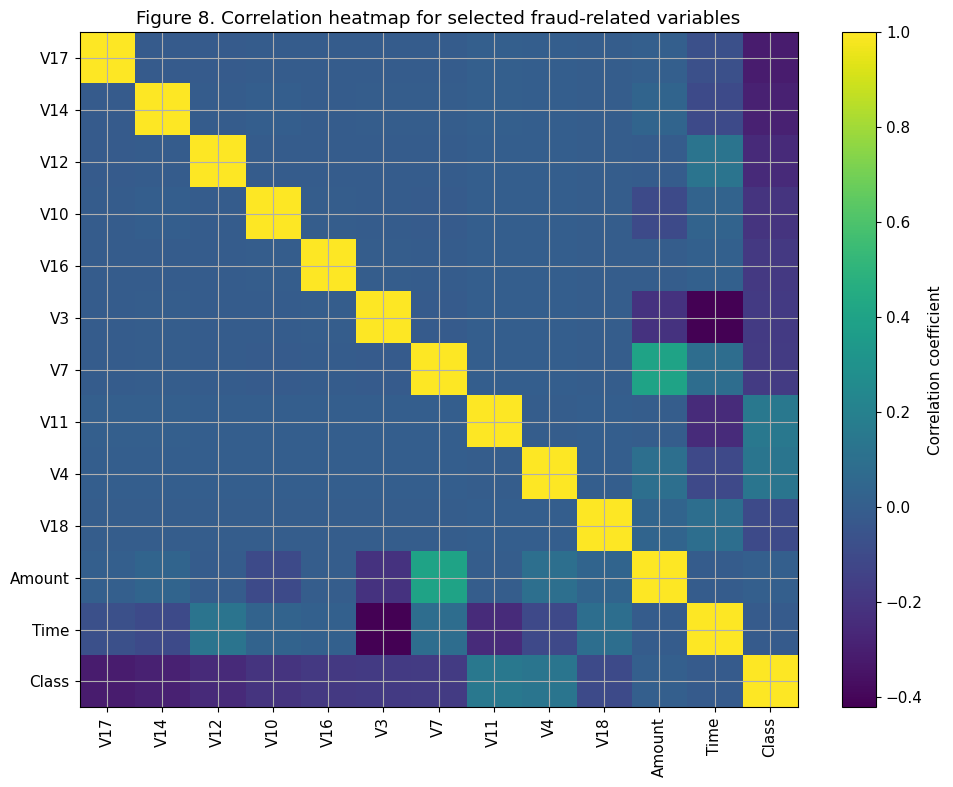


Saved files:
- table_6_feature_correlation_with_class.csv
- figure_7_top_feature_correlations_with_class.png
- figure_8_selected_feature_correlation_heatmap.png


In [6]:
# Chunk 6: I check correlations with the fraud target

correlation_matrix = df_clean.corr(numeric_only=True)

target_correlation = correlation_matrix["Class"].drop("Class").sort_values(key=abs, ascending=False)

print("Top 15 features most correlated with fraud class:")
display(target_correlation.head(15).to_frame("Correlation with Class"))

print("\nBottom 10 features least correlated with fraud class:")
display(target_correlation.tail(10).to_frame("Correlation with Class"))

# Figure 7: Top feature correlations with Class
top_corr = target_correlation.head(15)

plt.figure(figsize=(9, 6))
plt.barh(top_corr.index[::-1], top_corr.values[::-1])
plt.title("Figure 7. Top 15 feature correlations with the fraud class")
plt.xlabel("Correlation with Class")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(f"{output_folder}/figure_7_top_feature_correlations_with_class.png", dpi=300)
plt.show()

# Figure 8: Correlation heatmap for selected important variables
selected_features = top_corr.head(10).index.tolist() + ["Amount", "Time", "Class"]
selected_corr = df_clean[selected_features].corr(numeric_only=True)

plt.figure(figsize=(10, 8))
plt.imshow(selected_corr, aspect="auto")
plt.colorbar(label="Correlation coefficient")
plt.xticks(range(len(selected_corr.columns)), selected_corr.columns, rotation=90)
plt.yticks(range(len(selected_corr.index)), selected_corr.index)
plt.title("Figure 8. Correlation heatmap for selected fraud-related variables")
plt.tight_layout()
plt.savefig(f"{output_folder}/figure_8_selected_feature_correlation_heatmap.png", dpi=300)
plt.show()

# Save correlation table
target_correlation.to_frame("Correlation with Class").to_csv(
    f"{output_folder}/table_6_feature_correlation_with_class.csv"
)

print("\nSaved files:")
print("- table_6_feature_correlation_with_class.csv")
print("- figure_7_top_feature_correlations_with_class.png")
print("- figure_8_selected_feature_correlation_heatmap.png")

In [7]:
# Chunk 7: I prepare the cleaned data for modelling

X = df_clean.drop(columns=["Class"])
y = df_clean["Class"]

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

# I use stratification because the fraud class is extremely rare
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

train_class_table = pd.DataFrame({
    "Class": ["Legitimate", "Fraud"],
    "Count": y_train.value_counts().sort_index().values,
    "Percentage": (y_train.value_counts(normalize=True).sort_index() * 100).round(4).values
})

test_class_table = pd.DataFrame({
    "Class": ["Legitimate", "Fraud"],
    "Count": y_test.value_counts().sort_index().values,
    "Percentage": (y_test.value_counts(normalize=True).sort_index() * 100).round(4).values
})

print("\nTraining set class distribution:")
display(train_class_table)

print("\nTest set class distribution:")
display(test_class_table)

# I scale only Time and Amount because V1-V28 are already PCA-transformed
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

scaler = StandardScaler()

X_train_scaled[["Time", "Amount"]] = scaler.fit_transform(X_train[["Time", "Amount"]])
X_test_scaled[["Time", "Amount"]] = scaler.transform(X_test[["Time", "Amount"]])

print("\nScaled training data preview:")
display(X_train_scaled.head())

print("\nScaled test data preview:")
display(X_test_scaled.head())

split_summary = pd.DataFrame({
    "Dataset": ["Training set", "Test set"],
    "Rows": [X_train.shape[0], X_test.shape[0]],
    "Legitimate Count": [
        int(y_train.value_counts().sort_index().loc[0]),
        int(y_test.value_counts().sort_index().loc[0])
    ],
    "Fraud Count": [
        int(y_train.value_counts().sort_index().loc[1]),
        int(y_test.value_counts().sort_index().loc[1])
    ],
    "Fraud Percentage": [
        round(y_train.mean() * 100, 4),
        round(y_test.mean() * 100, 4)
    ]
})

print("\nTrain-test split summary:")
display(split_summary)

split_summary.to_csv(f"{output_folder}/table_7_train_test_split_summary.csv", index=False)

print("\nSaved file:")
print("- table_7_train_test_split_summary.csv")

Feature matrix shape: (283726, 30)
Target vector shape: (283726,)

Training set shape: (226980, 30)
Test set shape: (56746, 30)

Training set class distribution:


,Class,Count,Percentage
0,Legitimate,226602,99.8335
1,Fraud,378,0.1665



Test set class distribution:


,Class,Count,Percentage
0,Legitimate,56651,99.8326
1,Fraud,95,0.1674



Scaled training data preview:


...


Scaled test data preview:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
86568,-0.707761,1.228821,-0.063408,0.274145,0.647465,-0.048135,0.372073,-0.224231,0.079939,0.640759,...,-0.096566,-0.129554,-0.083779,-0.151661,-0.700372,0.598550,0.491409,0.002989,0.001782,-0.312846
251557,1.273872,-0.203154,1.176678,-0.759595,-0.518472,0.629649,-0.721675,0.638893,0.243377,-0.157488,...,-0.098429,0.384629,1.206754,-0.082753,0.508386,-0.710906,-0.234510,0.379640,0.261351,-0.351745
20232,-1.348111,-1.672836,1.401297,1.503940,2.175491,0.699791,1.062139,1.114364,-0.535822,-0.252983,...,0.828472,-0.525950,-0.408743,-0.280083,-0.846468,-0.155456,-0.062383,0.007777,0.113900,0.011771
68952,-0.878056,0.819379,-1.124913,0.515025,0.513945,-1.009048,0.488484,-0.580672,0.187686,-0.999142,...,-0.110144,-0.057205,-0.168061,-0.198732,-0.337408,0.238538,-0.289454,0.038214,0.058407,0.568071
191852,0.727104,2.009701,0.105635,-1.752759,0.588312,0.374801,-0.637884,0.009260,-0.129487,0.492619,...,-0.135479,0.008970,0.357394,-0.013472,-0.446920,0.111522,0.642944,-0.036998,-0.043404,-0.353901



Train-test split summary:


,Dataset,Rows,Legitimate Count,Fraud Count,Fraud Percentage
0,Training set,226980,226602,378,0.1665
1,Test set,56746,56651,95,0.1674



Saved file:
- table_7_train_test_split_summary.csv


In [8]:
# Chunk 8: I train baseline models and compare their first performance

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight="balanced"
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced"
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

baseline_results = []
baseline_predictions = {}

for model_name, model in models.items():
    print(f"\nTraining {model_name}...")

    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_prob = model.decision_function(X_test_scaled)

    baseline_predictions[model_name] = {
        "model": model,
        "y_pred": y_pred,
        "y_prob": y_prob
    }

    baseline_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "PR-AUC": average_precision_score(y_test, y_prob)
    })

baseline_results_df = pd.DataFrame(baseline_results)

metric_columns = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC", "PR-AUC"]
baseline_results_df[metric_columns] = baseline_results_df[metric_columns].round(4)

print("\nBaseline model comparison:")
display(baseline_results_df)

baseline_results_df.to_csv(f"{output_folder}/table_8_baseline_model_comparison.csv", index=False)

print("\nSaved file:")
print("- table_8_baseline_model_comparison.csv")


Training Logistic Regression...

Training Decision Tree...

Training Random Forest...

Training Gradient Boosting...

Baseline model comparison:


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,Logistic Regression,0.9752,0.0562,0.8737,0.1057,0.9658,0.6719
1,Decision Tree,0.9990,0.7349,0.6421,0.6854,0.8209,0.4725
2,Random Forest,0.9995,0.9710,0.7053,0.8171,0.9246,0.7960
3,Gradient Boosting,0.9992,0.8611,0.6526,0.7425,0.8539,0.6234



Saved file:
- table_8_baseline_model_comparison.csv



Classification report for Logistic Regression:
              precision    recall  f1-score   support

  Legitimate     0.9998    0.9754    0.9874     56651
       Fraud     0.0562    0.8737    0.1057        95

    accuracy                         0.9752     56746
   macro avg     0.5280    0.9245    0.5466     56746
weighted avg     0.9982    0.9752    0.9860     56746



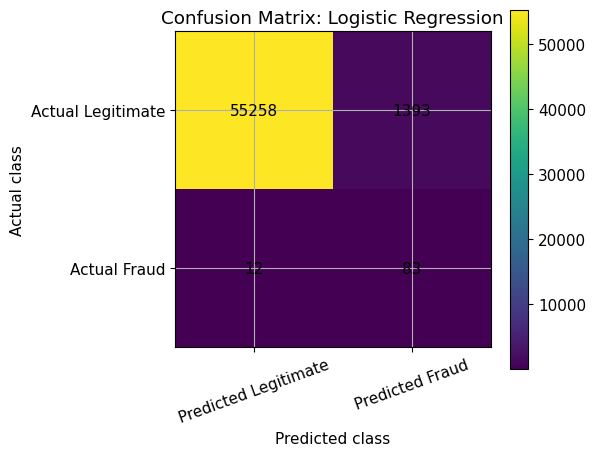


Classification report for Decision Tree:
              precision    recall  f1-score   support

  Legitimate     0.9994    0.9996    0.9995     56651
       Fraud     0.7349    0.6421    0.6854        95

    accuracy                         0.9990     56746
   macro avg     0.8672    0.8209    0.8424     56746
weighted avg     0.9990    0.9990    0.9990     56746



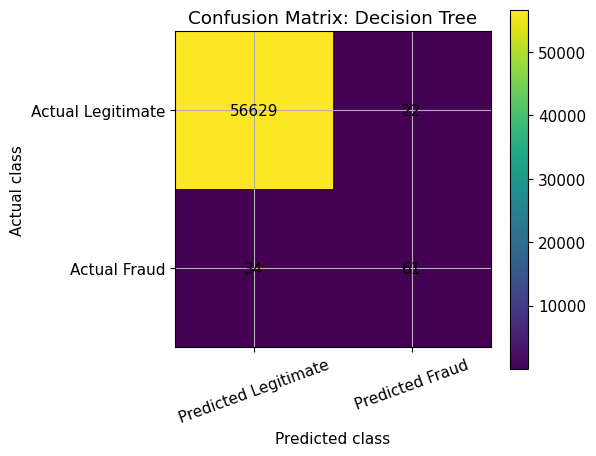


Classification report for Random Forest:
              precision    recall  f1-score   support

  Legitimate     0.9995    1.0000    0.9997     56651
       Fraud     0.9710    0.7053    0.8171        95

    accuracy                         0.9995     56746
   macro avg     0.9853    0.8526    0.9084     56746
weighted avg     0.9995    0.9995    0.9994     56746



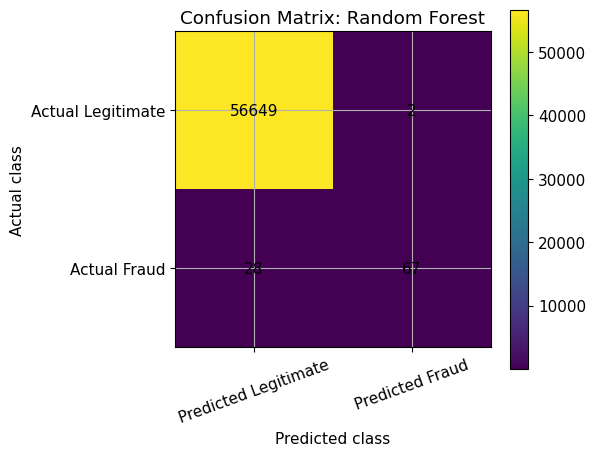


Classification report for Gradient Boosting:
              precision    recall  f1-score   support

  Legitimate     0.9994    0.9998    0.9996     56651
       Fraud     0.8611    0.6526    0.7425        95

    accuracy                         0.9992     56746
   macro avg     0.9303    0.8262    0.8711     56746
weighted avg     0.9992    0.9992    0.9992     56746



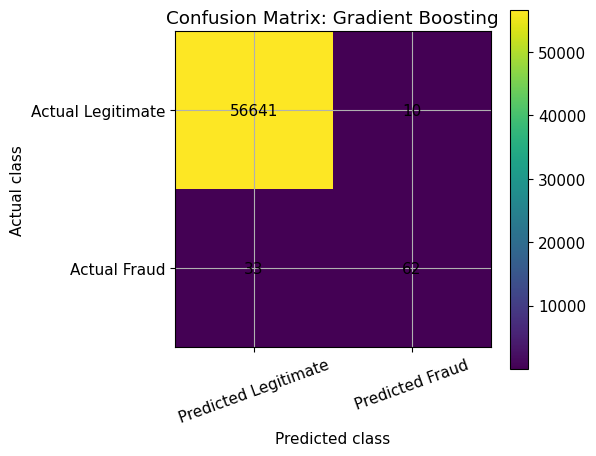


Confusion matrix summary:


,Model,True Negatives,False Positives,False Negatives,True Positives,Fraud Recall,Fraud Precision,Fraud F1-score
0,Logistic Regression,55258,1393,12,83,0.8737,0.0562,0.1057
1,Decision Tree,56629,22,34,61,0.6421,0.7349,0.6854
2,Random Forest,56649,2,28,67,0.7053,0.9710,0.8171
3,Gradient Boosting,56641,10,33,62,0.6526,0.8611,0.7425



Saved file:
- table_9_baseline_confusion_summary.csv
- confusion matrix figures for each baseline model


In [9]:
# Chunk 9: I examine false positives and false negatives for each baseline model

confusion_summary = []

for model_name, stored in baseline_predictions.items():
    y_pred = stored["y_pred"]

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    confusion_summary.append({
        "Model": model_name,
        "True Negatives": tn,
        "False Positives": fp,
        "False Negatives": fn,
        "True Positives": tp,
        "Fraud Recall": recall_score(y_test, y_pred, zero_division=0),
        "Fraud Precision": precision_score(y_test, y_pred, zero_division=0),
        "Fraud F1-score": f1_score(y_test, y_pred, zero_division=0)
    })

    print(f"\nClassification report for {model_name}:")
    print(classification_report(
        y_test,
        y_pred,
        target_names=["Legitimate", "Fraud"],
        digits=4,
        zero_division=0
    ))

    plt.figure(figsize=(6, 5))
    plt.imshow(cm, interpolation="nearest")
    plt.title(f"Confusion Matrix: {model_name}")
    plt.colorbar()
    plt.xticks([0, 1], ["Predicted Legitimate", "Predicted Fraud"], rotation=20)
    plt.yticks([0, 1], ["Actual Legitimate", "Actual Fraud"])

    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.xlabel("Predicted class")
    plt.ylabel("Actual class")
    plt.tight_layout()

    safe_name = model_name.lower().replace(" ", "_")
    plt.savefig(f"{output_folder}/figure_confusion_matrix_{safe_name}.png", dpi=300)
    plt.show()

confusion_summary_df = pd.DataFrame(confusion_summary)

confusion_summary_df[["Fraud Recall", "Fraud Precision", "Fraud F1-score"]] = confusion_summary_df[
    ["Fraud Recall", "Fraud Precision", "Fraud F1-score"]
].round(4)

print("\nConfusion matrix summary:")
display(confusion_summary_df)

confusion_summary_df.to_csv(f"{output_folder}/table_9_baseline_confusion_summary.csv", index=False)

print("\nSaved file:")
print("- table_9_baseline_confusion_summary.csv")
print("- confusion matrix figures for each baseline model")

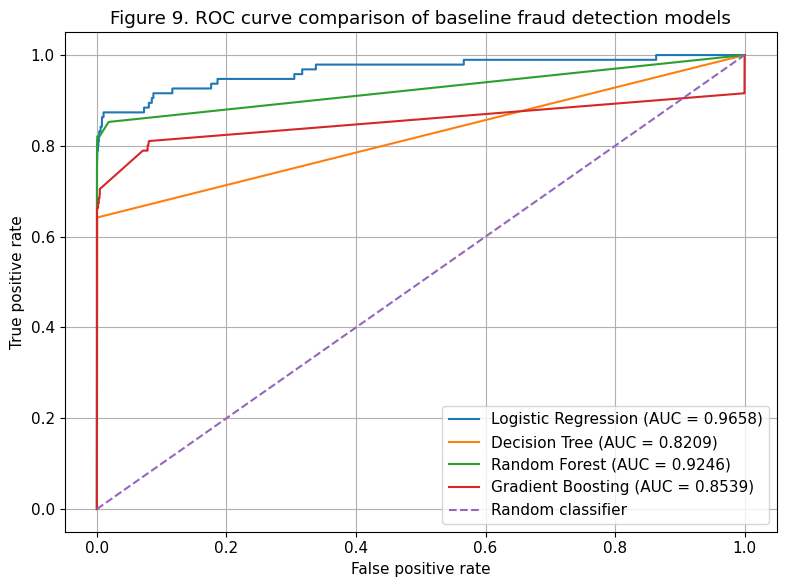

ROC-AUC comparison:


,Model,ROC-AUC
0,Logistic Regression,0.9658
1,Decision Tree,0.8209
2,Random Forest,0.9246
3,Gradient Boosting,0.8539


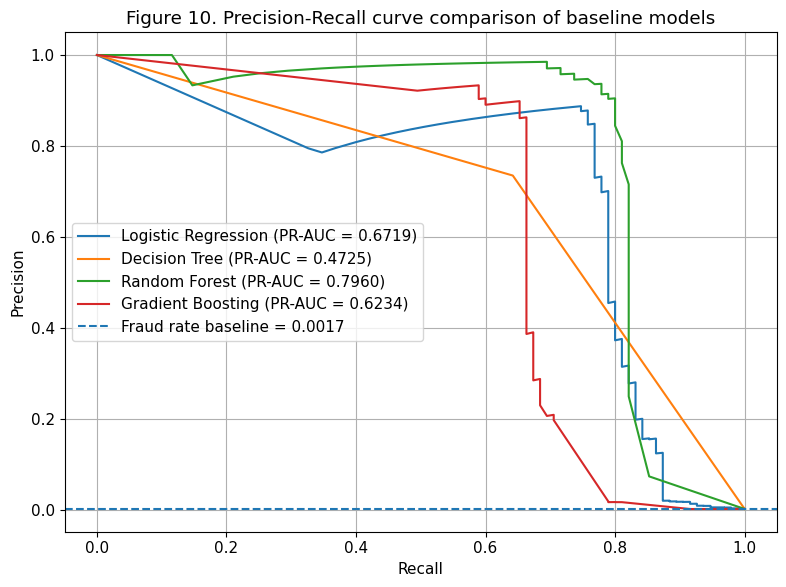


Precision-Recall AUC comparison:


,Model,PR-AUC
0,Logistic Regression,0.6719
1,Decision Tree,0.4725
2,Random Forest,0.7960
3,Gradient Boosting,0.6234



Saved files:
- table_10_roc_auc_comparison.csv
- table_11_pr_auc_comparison.csv
- figure_9_roc_curve_comparison.png
- figure_10_precision_recall_curve_comparison.png


In [10]:
# Chunk 10: I compare models using ROC and Precision-Recall curves

# ROC Curve
plt.figure(figsize=(8, 6))

roc_table_rows = []

for model_name, stored in baseline_predictions.items():
    y_prob = stored["y_prob"]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)

    roc_table_rows.append({
        "Model": model_name,
        "ROC-AUC": round(auc_score, 4)
    })

    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {auc_score:.4f})")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
plt.title("Figure 9. ROC curve comparison of baseline fraud detection models")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.legend()
plt.tight_layout()
plt.savefig(f"{output_folder}/figure_9_roc_curve_comparison.png", dpi=300)
plt.show()

roc_auc_table = pd.DataFrame(roc_table_rows)
print("ROC-AUC comparison:")
display(roc_auc_table)


# Precision-Recall Curve
plt.figure(figsize=(8, 6))

pr_table_rows = []

for model_name, stored in baseline_predictions.items():
    y_prob = stored["y_prob"]

    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)

    pr_table_rows.append({
        "Model": model_name,
        "PR-AUC": round(pr_auc, 4)
    })

    plt.plot(recall, precision, label=f"{model_name} (PR-AUC = {pr_auc:.4f})")

baseline_fraud_rate = y_test.mean()

plt.axhline(
    baseline_fraud_rate,
    linestyle="--",
    label=f"Fraud rate baseline = {baseline_fraud_rate:.4f}"
)

plt.title("Figure 10. Precision-Recall curve comparison of baseline models")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.tight_layout()
plt.savefig(f"{output_folder}/figure_10_precision_recall_curve_comparison.png", dpi=300)
plt.show()

pr_auc_table = pd.DataFrame(pr_table_rows)
print("\nPrecision-Recall AUC comparison:")
display(pr_auc_table)

roc_auc_table.to_csv(f"{output_folder}/table_10_roc_auc_comparison.csv", index=False)
pr_auc_table.to_csv(f"{output_folder}/table_11_pr_auc_comparison.csv", index=False)

print("\nSaved files:")
print("- table_10_roc_auc_comparison.csv")
print("- table_11_pr_auc_comparison.csv")
print("- figure_9_roc_curve_comparison.png")
print("- figure_10_precision_recall_curve_comparison.png")

Best threshold based on F1-score:


,Threshold,Accuracy,Precision,Recall,F1-score,False Positives,False Negatives,True Positives
16,0.21,0.9995,0.9367,0.7789,0.8506,5.0,21.0,74.0



Best threshold with precision at least 0.80:


,Threshold,Accuracy,Precision,Recall,F1-score,False Positives,False Negatives,True Positives
1,0.06,0.9994,0.8105,0.8105,0.8105,18,18,77



Top 10 threshold results by F1-score:


,Threshold,Accuracy,Precision,Recall,F1-score,False Positives,False Negatives,True Positives
16,0.21,0.9995,0.9367,0.7789,0.8506,5,21,74
14,0.19,0.9995,0.9146,0.7895,0.8475,7,20,75
13,0.18,0.9995,0.9146,0.7895,0.8475,7,20,75
9,0.14,0.9995,0.8941,0.8000,0.8444,9,19,76
17,0.22,0.9995,0.9359,0.7684,0.8439,5,22,73
12,0.17,0.9995,0.9036,0.7895,0.8427,8,20,75
11,0.16,0.9995,0.9036,0.7895,0.8427,8,20,75
10,0.15,0.9995,0.9036,0.7895,0.8427,8,20,75
18,0.23,0.9995,0.9474,0.7579,0.8421,4,23,72
15,0.20,0.9995,0.9136,0.7789,0.8409,7,21,74


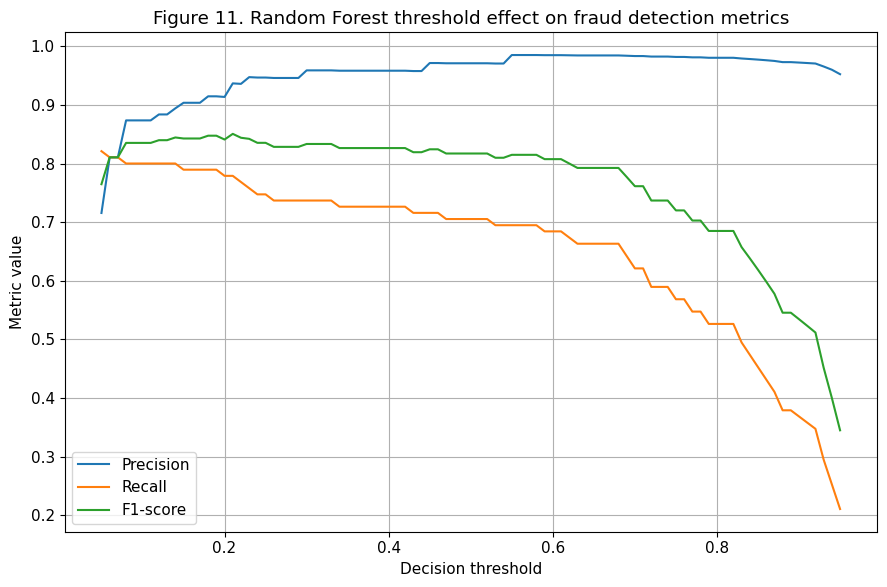

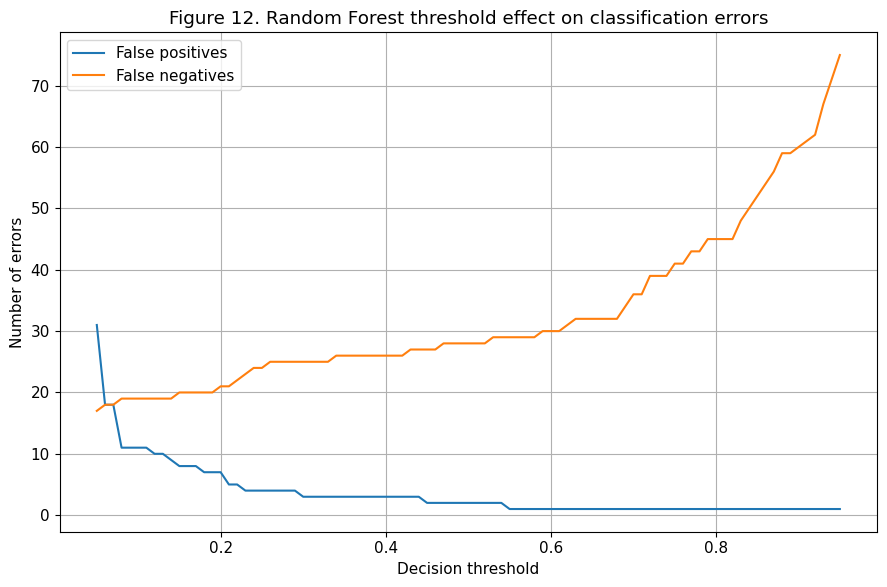


Saved files:
- table_12_random_forest_threshold_results.csv
- figure_11_random_forest_threshold_metrics.png
- figure_12_random_forest_threshold_errors.png


In [11]:
# Chunk 11: I tune the decision threshold for the Random Forest model

rf_model = baseline_predictions["Random Forest"]["model"]
rf_probs = baseline_predictions["Random Forest"]["y_prob"]

thresholds = np.arange(0.05, 0.96, 0.01)

threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (rf_probs >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test, y_pred_threshold),
        "Precision": precision_score(y_test, y_pred_threshold, zero_division=0),
        "Recall": recall_score(y_test, y_pred_threshold, zero_division=0),
        "F1-score": f1_score(y_test, y_pred_threshold, zero_division=0),
        "False Positives": confusion_matrix(y_test, y_pred_threshold).ravel()[1],
        "False Negatives": confusion_matrix(y_test, y_pred_threshold).ravel()[2],
        "True Positives": confusion_matrix(y_test, y_pred_threshold).ravel()[3]
    })

threshold_results_df = pd.DataFrame(threshold_results)

best_f1_row = threshold_results_df.loc[threshold_results_df["F1-score"].idxmax()]
best_recall_controlled_row = threshold_results_df[
    threshold_results_df["Precision"] >= 0.80
].sort_values("Recall", ascending=False).head(1)

print("Best threshold based on F1-score:")
display(best_f1_row.to_frame().T.round(4))

print("\nBest threshold with precision at least 0.80:")
display(best_recall_controlled_row.round(4))

print("\nTop 10 threshold results by F1-score:")
display(
    threshold_results_df.sort_values("F1-score", ascending=False)
    .head(10)
    .round(4)
)

# Figure 11: Threshold effect on precision, recall and F1-score
plt.figure(figsize=(9, 6))
plt.plot(threshold_results_df["Threshold"], threshold_results_df["Precision"], label="Precision")
plt.plot(threshold_results_df["Threshold"], threshold_results_df["Recall"], label="Recall")
plt.plot(threshold_results_df["Threshold"], threshold_results_df["F1-score"], label="F1-score")
plt.title("Figure 11. Random Forest threshold effect on fraud detection metrics")
plt.xlabel("Decision threshold")
plt.ylabel("Metric value")
plt.legend()
plt.tight_layout()
plt.savefig(f"{output_folder}/figure_11_random_forest_threshold_metrics.png", dpi=300)
plt.show()

# Figure 12: Threshold effect on false positives and false negatives
plt.figure(figsize=(9, 6))
plt.plot(threshold_results_df["Threshold"], threshold_results_df["False Positives"], label="False positives")
plt.plot(threshold_results_df["Threshold"], threshold_results_df["False Negatives"], label="False negatives")
plt.title("Figure 12. Random Forest threshold effect on classification errors")
plt.xlabel("Decision threshold")
plt.ylabel("Number of errors")
plt.legend()
plt.tight_layout()
plt.savefig(f"{output_folder}/figure_12_random_forest_threshold_errors.png", dpi=300)
plt.show()

threshold_results_df.to_csv(f"{output_folder}/table_12_random_forest_threshold_results.csv", index=False)

print("\nSaved files:")
print("- table_12_random_forest_threshold_results.csv")
print("- figure_11_random_forest_threshold_metrics.png")
print("- figure_12_random_forest_threshold_errors.png")

Top 15 Random Forest feature importances:


,Feature,Importance
14,V14,0.185744
10,V10,0.120414
12,V12,0.100224
17,V17,0.093938
4,V4,0.093173
3,V3,0.059786
16,V16,0.056195
11,V11,0.053734
2,V2,0.035560
9,V9,0.025835



Bottom 10 Random Forest feature importances:


,Feature,Importance
6,V6,0.007835
29,Amount,0.007380
26,V26,0.006779
15,V15,0.006762
25,V25,0.005223
24,V24,0.005152
22,V22,0.005038
23,V23,0.005027
28,V28,0.004896
0,Time,0.003778


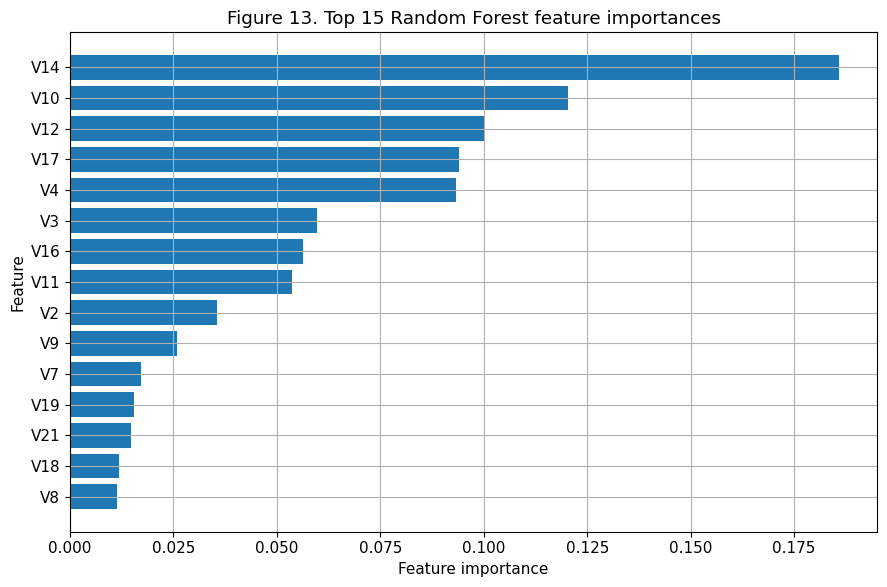


Saved files:
- table_13_random_forest_feature_importance.csv
- figure_13_random_forest_feature_importance.png


In [12]:
# Chunk 12: I extract feature importance from the Random Forest model

feature_importance = pd.DataFrame({
    "Feature": X_train_scaled.columns,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

feature_importance["Importance"] = feature_importance["Importance"].round(6)

print("Top 15 Random Forest feature importances:")
display(feature_importance.head(15))

print("\nBottom 10 Random Forest feature importances:")
display(feature_importance.tail(10))

# Figure 13: Top 15 feature importances
top_features = feature_importance.head(15)

plt.figure(figsize=(9, 6))
plt.barh(top_features["Feature"][::-1], top_features["Importance"][::-1])
plt.title("Figure 13. Top 15 Random Forest feature importances")
plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(f"{output_folder}/figure_13_random_forest_feature_importance.png", dpi=300)
plt.show()

feature_importance.to_csv(
    f"{output_folder}/table_13_random_forest_feature_importance.csv",
    index=False
)

print("\nSaved files:")
print("- table_13_random_forest_feature_importance.csv")
print("- figure_13_random_forest_feature_importance.png")

Exact best threshold selected from tuning table:
0.21000000000000002

Corrected final tuned Random Forest results:


,Model,Threshold,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC,True Negatives,False Positives,False Negatives,True Positives
0,Random Forest with tuned threshold,0.21,0.9995,0.9367,0.7789,0.8506,0.9246,0.796,56646,5,21,74



Corrected classification report for final tuned Random Forest:
              precision    recall  f1-score   support

  Legitimate     0.9996    0.9999    0.9998     56651
       Fraud     0.9367    0.7789    0.8506        95

    accuracy                         0.9995     56746
   macro avg     0.9682    0.8894    0.9252     56746
weighted avg     0.9995    0.9995    0.9995     56746



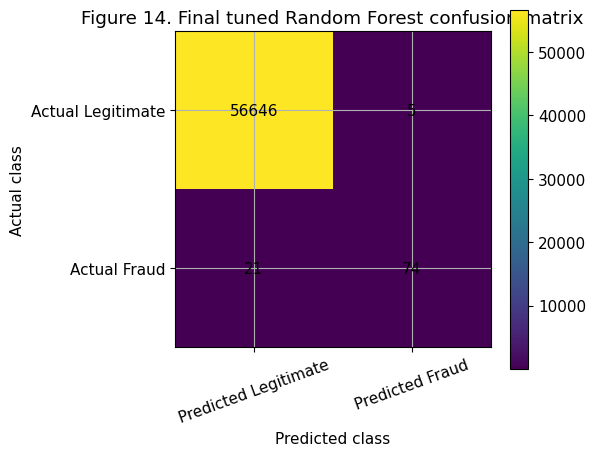


Saved corrected files:
- table_14_final_tuned_rf_results.csv
- figure_14_final_tuned_rf_confusion_matrix.png


In [14]:
# Chunk 13: I use the exact best threshold from the threshold tuning table

best_threshold_exact = threshold_results_df.loc[
    threshold_results_df["F1-score"].idxmax(), "Threshold"
]

print("Exact best threshold selected from tuning table:")
print(best_threshold_exact)

final_rf_probs = rf_probs
final_rf_pred = (final_rf_probs >= best_threshold_exact).astype(int)

final_cm = confusion_matrix(y_test, final_rf_pred)
tn, fp, fn, tp = final_cm.ravel()

final_rf_results = pd.DataFrame({
    "Model": ["Random Forest with tuned threshold"],
    "Threshold": [best_threshold_exact],
    "Accuracy": [accuracy_score(y_test, final_rf_pred)],
    "Precision": [precision_score(y_test, final_rf_pred, zero_division=0)],
    "Recall": [recall_score(y_test, final_rf_pred, zero_division=0)],
    "F1-score": [f1_score(y_test, final_rf_pred, zero_division=0)],
    "ROC-AUC": [roc_auc_score(y_test, final_rf_probs)],
    "PR-AUC": [average_precision_score(y_test, final_rf_probs)],
    "True Negatives": [tn],
    "False Positives": [fp],
    "False Negatives": [fn],
    "True Positives": [tp]
})

round_cols = ["Threshold", "Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC", "PR-AUC"]
final_rf_results[round_cols] = final_rf_results[round_cols].round(4)

print("\nCorrected final tuned Random Forest results:")
display(final_rf_results)

print("\nCorrected classification report for final tuned Random Forest:")
print(classification_report(
    y_test,
    final_rf_pred,
    target_names=["Legitimate", "Fraud"],
    digits=4,
    zero_division=0
))

plt.figure(figsize=(6, 5))
plt.imshow(final_cm, interpolation="nearest")
plt.title("Figure 14. Final tuned Random Forest confusion matrix")
plt.colorbar()
plt.xticks([0, 1], ["Predicted Legitimate", "Predicted Fraud"], rotation=20)
plt.yticks([0, 1], ["Actual Legitimate", "Actual Fraud"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, final_cm[i, j], ha="center", va="center")

plt.xlabel("Predicted class")
plt.ylabel("Actual class")
plt.tight_layout()
plt.savefig(f"{output_folder}/figure_14_final_tuned_rf_confusion_matrix.png", dpi=300)
plt.show()

final_rf_results.to_csv(f"{output_folder}/table_14_final_tuned_rf_results.csv", index=False)

print("\nSaved corrected files:")
print("- table_14_final_tuned_rf_results.csv")
print("- figure_14_final_tuned_rf_confusion_matrix.png")

Training fraud rate:
0.001665

Training Isolation Forest...

Isolation Forest results:


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC,True Negatives,False Positives,False Negatives,True Positives
0,Isolation Forest,0.9974,0.2022,0.1895,0.1957,0.9304,0.104,56580,71,77,18



Classification report for Isolation Forest:
              precision    recall  f1-score   support

  Legitimate     0.9986    0.9987    0.9987     56651
       Fraud     0.2022    0.1895    0.1957        95

    accuracy                         0.9974     56746
   macro avg     0.6004    0.5941    0.5972     56746
weighted avg     0.9973    0.9974    0.9973     56746



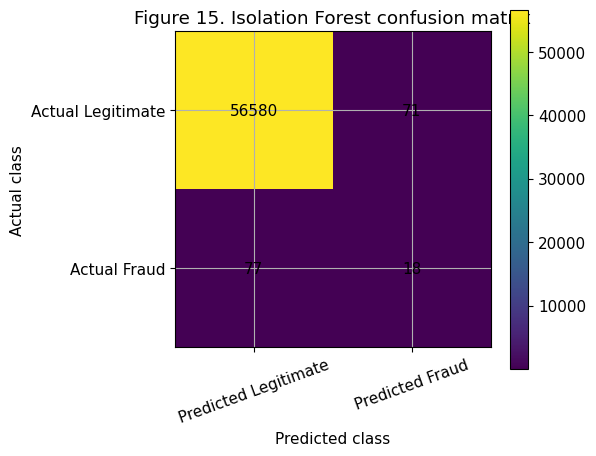


Saved files:
- table_15_isolation_forest_results.csv
- figure_15_isolation_forest_confusion_matrix.png


In [15]:
# Chunk 14: I test Isolation Forest as an unsupervised anomaly detection method

fraud_rate = y_train.mean()

print("Training fraud rate:")
print(f"{fraud_rate:.6f}")

iso_forest = IsolationForest(
    n_estimators=200,
    contamination=fraud_rate,
    random_state=42,
    n_jobs=-1
)

print("\nTraining Isolation Forest...")
iso_forest.fit(X_train_scaled)

# Isolation Forest predicts -1 for anomaly and 1 for normal
iso_pred_raw = iso_forest.predict(X_test_scaled)
iso_pred = np.where(iso_pred_raw == -1, 1, 0)

# Higher score should mean more likely fraud, so I multiply by -1
iso_scores = -iso_forest.decision_function(X_test_scaled)

iso_cm = confusion_matrix(y_test, iso_pred)
tn, fp, fn, tp = iso_cm.ravel()

iso_results = pd.DataFrame({
    "Model": ["Isolation Forest"],
    "Accuracy": [accuracy_score(y_test, iso_pred)],
    "Precision": [precision_score(y_test, iso_pred, zero_division=0)],
    "Recall": [recall_score(y_test, iso_pred, zero_division=0)],
    "F1-score": [f1_score(y_test, iso_pred, zero_division=0)],
    "ROC-AUC": [roc_auc_score(y_test, iso_scores)],
    "PR-AUC": [average_precision_score(y_test, iso_scores)],
    "True Negatives": [tn],
    "False Positives": [fp],
    "False Negatives": [fn],
    "True Positives": [tp]
})

metric_cols = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC", "PR-AUC"]
iso_results[metric_cols] = iso_results[metric_cols].round(4)

print("\nIsolation Forest results:")
display(iso_results)

print("\nClassification report for Isolation Forest:")
print(classification_report(
    y_test,
    iso_pred,
    target_names=["Legitimate", "Fraud"],
    digits=4,
    zero_division=0
))

plt.figure(figsize=(6, 5))
plt.imshow(iso_cm, interpolation="nearest")
plt.title("Figure 15. Isolation Forest confusion matrix")
plt.colorbar()
plt.xticks([0, 1], ["Predicted Legitimate", "Predicted Fraud"], rotation=20)
plt.yticks([0, 1], ["Actual Legitimate", "Actual Fraud"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, iso_cm[i, j], ha="center", va="center")

plt.xlabel("Predicted class")
plt.ylabel("Actual class")
plt.tight_layout()
plt.savefig(f"{output_folder}/figure_15_isolation_forest_confusion_matrix.png", dpi=300)
plt.show()

iso_results.to_csv(f"{output_folder}/table_15_isolation_forest_results.csv", index=False)

print("\nSaved files:")
print("- table_15_isolation_forest_results.csv")
print("- figure_15_isolation_forest_confusion_matrix.png")

Final model comparison sorted by F1-score:


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC,True Negatives,False Positives,False Negatives,True Positives
0,Tuned Random Forest,0.9995,0.9367,0.7789,0.8506,0.9246,0.7960,56646,5,21,74
1,Random Forest,0.9995,0.9710,0.7053,0.8171,0.9246,0.7960,56649,2,28,67
2,Gradient Boosting,0.9992,0.8611,0.6526,0.7425,0.8539,0.6234,56641,10,33,62
3,Decision Tree,0.9990,0.7349,0.6421,0.6854,0.8209,0.4725,56629,22,34,61
4,Isolation Forest,0.9974,0.2022,0.1895,0.1957,0.9304,0.1040,56580,71,77,18
5,Logistic Regression,0.9752,0.0562,0.8737,0.1057,0.9658,0.6719,55258,1393,12,83


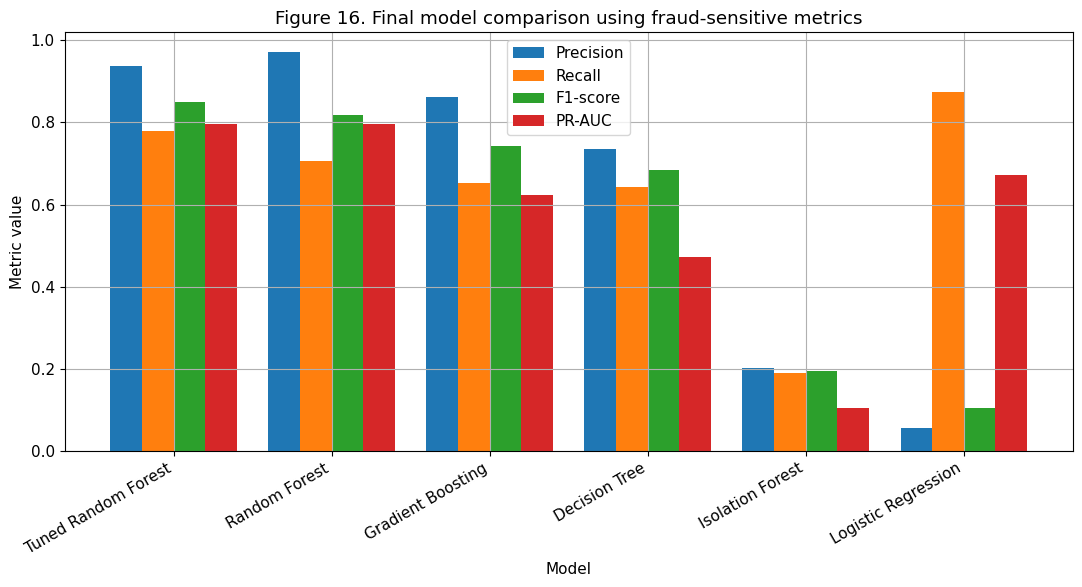


Saved files:
- table_16_final_model_comparison.csv
- figure_16_final_model_metric_comparison.png


In [16]:
# Chunk 15: I combine all model results into one final comparison table

baseline_compact = baseline_results_df.copy()

# Add confusion values from baseline confusion summary
baseline_compact = baseline_compact.merge(
    confusion_summary_df[
        ["Model", "True Negatives", "False Positives", "False Negatives", "True Positives"]
    ],
    on="Model",
    how="left"
)

final_rf_compact = final_rf_results.copy()
final_rf_compact["Model"] = "Tuned Random Forest"

iso_compact = iso_results.copy()

final_model_comparison = pd.concat(
    [
        baseline_compact,
        final_rf_compact[
            [
                "Model", "Accuracy", "Precision", "Recall", "F1-score",
                "ROC-AUC", "PR-AUC", "True Negatives", "False Positives",
                "False Negatives", "True Positives"
            ]
        ],
        iso_compact[
            [
                "Model", "Accuracy", "Precision", "Recall", "F1-score",
                "ROC-AUC", "PR-AUC", "True Negatives", "False Positives",
                "False Negatives", "True Positives"
            ]
        ]
    ],
    ignore_index=True
)

metric_cols = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC", "PR-AUC"]
final_model_comparison[metric_cols] = final_model_comparison[metric_cols].round(4)

final_model_comparison = final_model_comparison.sort_values(
    by="F1-score",
    ascending=False
).reset_index(drop=True)

print("Final model comparison sorted by F1-score:")
display(final_model_comparison)

final_model_comparison.to_csv(
    f"{output_folder}/table_16_final_model_comparison.csv",
    index=False
)

# Figure 16: Final model comparison by key fraud metrics
plot_metrics = final_model_comparison.set_index("Model")[["Precision", "Recall", "F1-score", "PR-AUC"]]

plt.figure(figsize=(11, 6))
x = np.arange(len(plot_metrics.index))
width = 0.2

for i, metric in enumerate(plot_metrics.columns):
    plt.bar(x + i * width, plot_metrics[metric], width, label=metric)

plt.xticks(x + width * 1.5, plot_metrics.index, rotation=30, ha="right")
plt.title("Figure 16. Final model comparison using fraud-sensitive metrics")
plt.xlabel("Model")
plt.ylabel("Metric value")
plt.legend()
plt.tight_layout()
plt.savefig(f"{output_folder}/figure_16_final_model_metric_comparison.png", dpi=300)
plt.show()

print("\nSaved files:")
print("- table_16_final_model_comparison.csv")
print("- figure_16_final_model_metric_comparison.png")

In [17]:
# Chunk 16: I create a cleaner train-validation-test split for final model selection

X = df_clean.drop(columns=["Class"])
y = df_clean["Class"]

# First, I keep 20% as the untouched final test set
X_temp, X_final_test, y_temp, y_final_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Then I split the remaining 80% into training and validation
# This gives roughly 60% train, 20% validation, 20% final test
X_final_train, X_validation, y_final_train, y_validation = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    random_state=42,
    stratify=y_temp
)

print("Final training set shape:", X_final_train.shape)
print("Validation set shape:", X_validation.shape)
print("Final test set shape:", X_final_test.shape)

split_check = pd.DataFrame({
    "Dataset": ["Training", "Validation", "Final Test"],
    "Rows": [len(y_final_train), len(y_validation), len(y_final_test)],
    "Legitimate Count": [
        int((y_final_train == 0).sum()),
        int((y_validation == 0).sum()),
        int((y_final_test == 0).sum())
    ],
    "Fraud Count": [
        int((y_final_train == 1).sum()),
        int((y_validation == 1).sum()),
        int((y_final_test == 1).sum())
    ],
    "Fraud Percentage": [
        round(y_final_train.mean() * 100, 4),
        round(y_validation.mean() * 100, 4),
        round(y_final_test.mean() * 100, 4)
    ]
})

print("\nCorrected train-validation-test split summary:")
display(split_check)

# I scale only Time and Amount using the training set only
final_scaler = StandardScaler()

X_final_train_scaled = X_final_train.copy()
X_validation_scaled = X_validation.copy()
X_final_test_scaled = X_final_test.copy()

X_final_train_scaled[["Time", "Amount"]] = final_scaler.fit_transform(
    X_final_train[["Time", "Amount"]]
)

X_validation_scaled[["Time", "Amount"]] = final_scaler.transform(
    X_validation[["Time", "Amount"]]
)

X_final_test_scaled[["Time", "Amount"]] = final_scaler.transform(
    X_final_test[["Time", "Amount"]]
)

split_check.to_csv(f"{output_folder}/table_17_corrected_train_validation_test_split.csv", index=False)

print("\nSaved file:")
print("- table_17_corrected_train_validation_test_split.csv")

Final training set shape: (170235, 30)
Validation set shape: (56745, 30)
Final test set shape: (56746, 30)

Corrected train-validation-test split summary:


,Dataset,Rows,Legitimate Count,Fraud Count,Fraud Percentage
0,Training,170235,169951,284,0.1668
1,Validation,56745,56651,94,0.1657
2,Final Test,56746,56651,95,0.1674



Saved file:
- table_17_corrected_train_validation_test_split.csv


Training final Random Forest model...
Best validation threshold based on F1-score:
0.31000000000000005

Top 10 validation threshold results:


,Threshold,Accuracy,Precision,Recall,F1-score,False Positives,False Negatives,True Positives
26,0.31,0.9997,0.9412,0.8511,0.8939,5,14,80
28,0.33,0.9997,0.9412,0.8511,0.8939,5,14,80
27,0.32,0.9997,0.9412,0.8511,0.8939,5,14,80
34,0.39,0.9997,0.9518,0.8404,0.8927,4,15,79
33,0.38,0.9997,0.9518,0.8404,0.8927,4,15,79
35,0.40,0.9997,0.9518,0.8404,0.8927,4,15,79
36,0.41,0.9997,0.9518,0.8404,0.8927,4,15,79
23,0.28,0.9996,0.9205,0.8617,0.8901,7,13,81
22,0.27,0.9996,0.9205,0.8617,0.8901,7,13,81
21,0.26,0.9996,0.9205,0.8617,0.8901,7,13,81


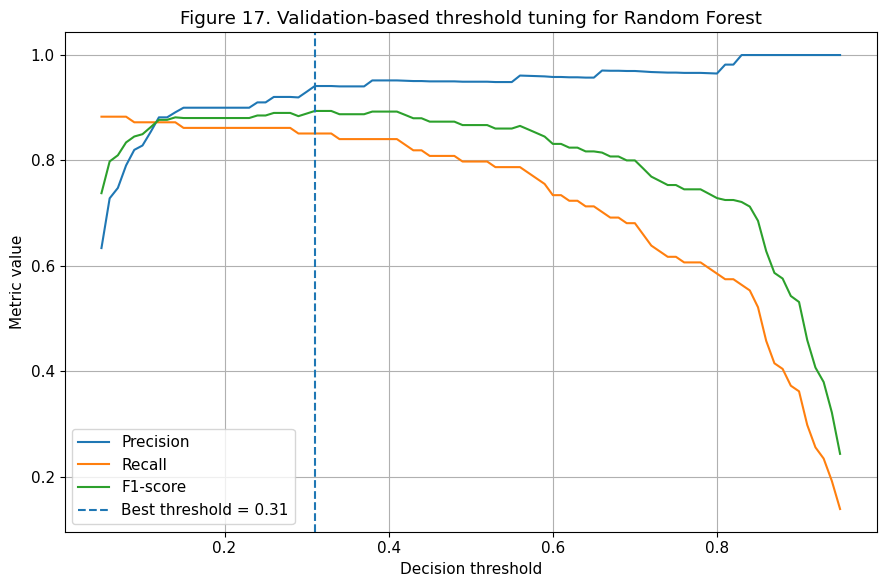

In [19]:
# Chunk 17: I train Random Forest on training data and tune threshold only on validation data

final_rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

print("Training final Random Forest model...")
final_rf_model.fit(X_final_train_scaled, y_final_train)

validation_probs = final_rf_model.predict_proba(X_validation_scaled)[:, 1]

validation_thresholds = np.arange(0.05, 0.96, 0.01)
validation_threshold_results = []

for threshold in validation_thresholds:
    val_pred = (validation_probs >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_validation, val_pred).ravel()

    validation_threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_validation, val_pred),
        "Precision": precision_score(y_validation, val_pred, zero_division=0),
        "Recall": recall_score(y_validation, val_pred, zero_division=0),
        "F1-score": f1_score(y_validation, val_pred, zero_division=0),
        "False Positives": fp,
        "False Negatives": fn,
        "True Positives": tp
    })

validation_threshold_results_df = pd.DataFrame(validation_threshold_results)

best_validation_threshold = validation_threshold_results_df.loc[
    validation_threshold_results_df["F1-score"].idxmax(), "Threshold"
]

print("Best validation threshold based on F1-score:")
print(best_validation_threshold)

print("\nTop 10 validation threshold results:")
display(
    validation_threshold_results_df
    .sort_values("F1-score", ascending=False)
    .head(10)
    .round(4)
)

plt.figure(figsize=(9, 6))
plt.plot(validation_threshold_results_df["Threshold"], validation_threshold_results_df["Precision"], label="Precision")
plt.plot(validation_threshold_results_df["Threshold"], validation_threshold_results_df["Recall"], label="Recall")
plt.plot(validation_threshold_results_df["Threshold"], validation_threshold_results_df["F1-score"], label="F1-score")
plt.axvline(best_validation_threshold, linestyle="--", label=f"Best threshold = {best_validation_threshold:.2f}")
plt.title("Figure 17. Validation-based threshold tuning for Random Forest")
plt.xlabel("Decision threshold")
plt.ylabel("Metric value")
plt.legend()
plt.tight_layout()
plt.savefig(f"{output_folder}/figure_17_validation_threshold_tuning.png", dpi=300)
plt.show()

validation_threshold_results_df.to_csv(
    f"{output_folder}/table_18_validation_threshold_tuning.csv",
    index=False
)

In [20]:
# Chunk 18: I evaluate the final model once on the untouched final test set

final_test_probs = final_rf_model.predict_proba(X_final_test_scaled)[:, 1]
final_test_pred = (final_test_probs >= best_validation_threshold).astype(int)

final_test_cm = confusion_matrix(y_final_test, final_test_pred)
tn, fp, fn, tp = final_test_cm.ravel()

corrected_final_results = pd.DataFrame({
    "Model": ["Random Forest"],
    "Threshold selected on validation set": [best_validation_threshold],
    "Accuracy": [accuracy_score(y_final_test, final_test_pred)],
    "Precision": [precision_score(y_final_test, final_test_pred, zero_division=0)],
    "Recall": [recall_score(y_final_test, final_test_pred, zero_division=0)],
    "F1-score": [f1_score(y_final_test, final_test_pred, zero_division=0)],
    "ROC-AUC": [roc_auc_score(y_final_test, final_test_probs)],
    "PR-AUC": [average_precision_score(y_final_test, final_test_probs)],
    "True Negatives": [tn],
    "False Positives": [fp],
    "False Negatives": [fn],
    "True Positives": [tp]
})

round_cols = [
    "Threshold selected on validation set", "Accuracy", "Precision",
    "Recall", "F1-score", "ROC-AUC", "PR-AUC"
]

corrected_final_results[round_cols] = corrected_final_results[round_cols].round(4)

print("Corrected final test results:")
display(corrected_final_results)

print("\nFinal test classification report:")
print(classification_report(
    y_final_test,
    final_test_pred,
    target_names=["Legitimate", "Fraud"],
    digits=4,
    zero_division=0
))

corrected_final_results.to_csv(
    f"{output_folder}/table_19_corrected_final_test_results.csv",
    index=False
)

Corrected final test results:


,Model,Threshold selected on validation set,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC,True Negatives,False Positives,False Negatives,True Positives
0,Random Forest,0.31,0.9995,0.9459,0.7368,0.8284,0.945,0.8195,56647,4,25,70



Final test classification report:
              precision    recall  f1-score   support

  Legitimate     0.9996    0.9999    0.9997     56651
       Fraud     0.9459    0.7368    0.8284        95

    accuracy                         0.9995     56746
   macro avg     0.9728    0.8684    0.9141     56746
weighted avg     0.9995    0.9995    0.9995     56746



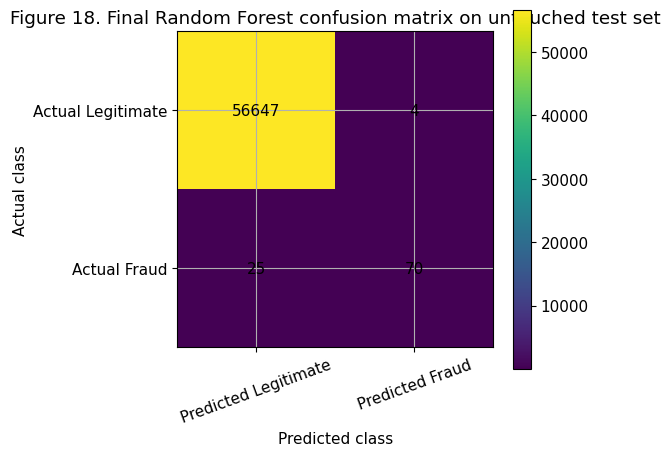

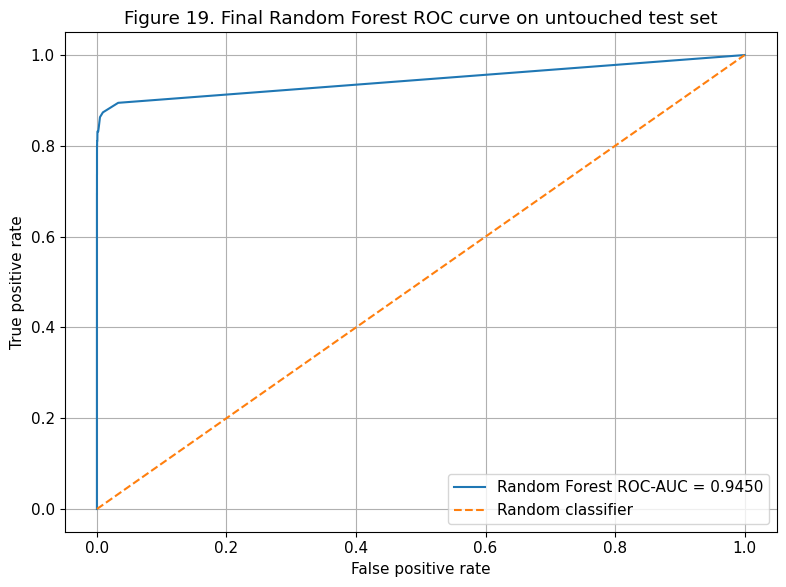

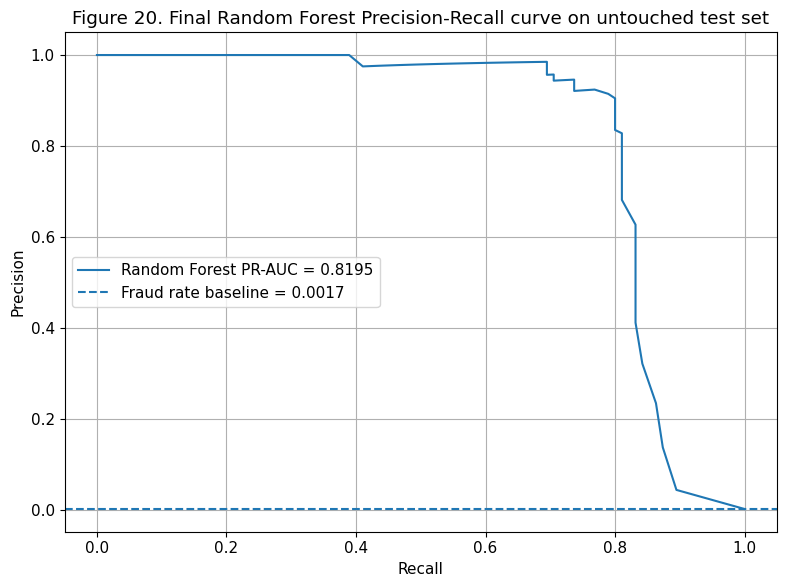

Final curve summary:


,Metric,Value
0,ROC-AUC,0.944984
1,PR-AUC,0.819482
2,Fraud rate baseline,0.001674


In [21]:
# Chunk 19: I create final confusion matrix, ROC curve and Precision-Recall curve

plt.figure(figsize=(6, 5))
plt.imshow(final_test_cm, interpolation="nearest")
plt.title("Figure 18. Final Random Forest confusion matrix on untouched test set")
plt.colorbar()
plt.xticks([0, 1], ["Predicted Legitimate", "Predicted Fraud"], rotation=20)
plt.yticks([0, 1], ["Actual Legitimate", "Actual Fraud"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, final_test_cm[i, j], ha="center", va="center")

plt.xlabel("Predicted class")
plt.ylabel("Actual class")
plt.tight_layout()
plt.savefig(f"{output_folder}/figure_18_final_test_confusion_matrix.png", dpi=300)
plt.show()


fpr, tpr, _ = roc_curve(y_final_test, final_test_probs)
final_roc_auc = roc_auc_score(y_final_test, final_test_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Random Forest ROC-AUC = {final_roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
plt.title("Figure 19. Final Random Forest ROC curve on untouched test set")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.legend()
plt.tight_layout()
plt.savefig(f"{output_folder}/figure_19_final_test_roc_curve.png", dpi=300)
plt.show()


precision_curve, recall_curve, _ = precision_recall_curve(y_final_test, final_test_probs)
final_pr_auc = average_precision_score(y_final_test, final_test_probs)

plt.figure(figsize=(8, 6))
plt.plot(recall_curve, precision_curve, label=f"Random Forest PR-AUC = {final_pr_auc:.4f}")
plt.axhline(y_final_test.mean(), linestyle="--", label=f"Fraud rate baseline = {y_final_test.mean():.4f}")
plt.title("Figure 20. Final Random Forest Precision-Recall curve on untouched test set")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.tight_layout()
plt.savefig(f"{output_folder}/figure_20_final_test_precision_recall_curve.png", dpi=300)
plt.show()

final_curve_summary = pd.DataFrame({
    "Metric": ["ROC-AUC", "PR-AUC", "Fraud rate baseline"],
    "Value": [final_roc_auc, final_pr_auc, y_final_test.mean()]
})

final_curve_summary["Value"] = final_curve_summary["Value"].round(6)

print("Final curve summary:")
display(final_curve_summary)

final_curve_summary.to_csv(
    f"{output_folder}/table_20_final_curve_summary.csv",
    index=False
)

Top 15 final Random Forest feature importances:


,Feature,Importance
14,V14,0.181879
10,V10,0.113665
4,V4,0.111356
12,V12,0.102814
17,V17,0.094991
3,V3,0.069678
11,V11,0.049569
16,V16,0.042433
2,V2,0.028392
7,V7,0.027516


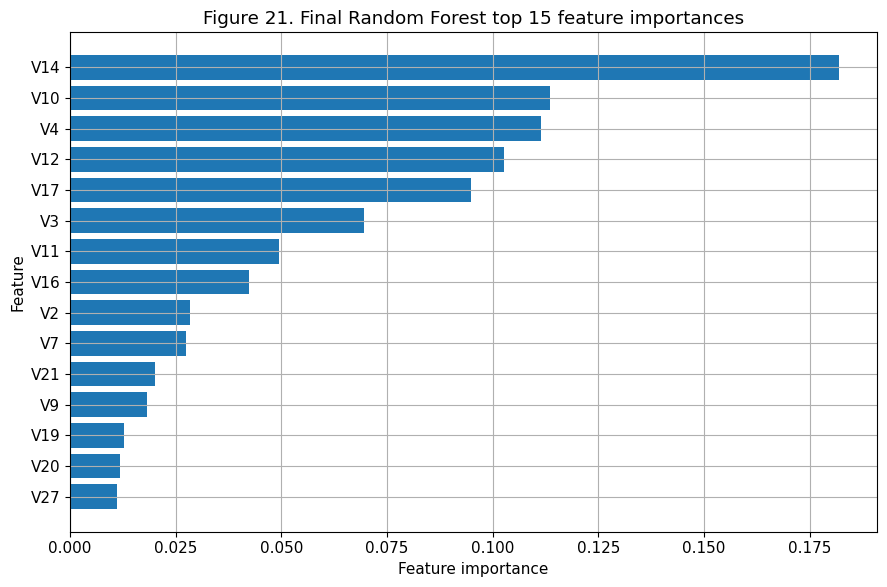

In [22]:
# Chunk 20: I extract final feature importance from the corrected Random Forest model

corrected_feature_importance = pd.DataFrame({
    "Feature": X_final_train_scaled.columns,
    "Importance": final_rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

corrected_feature_importance["Importance"] = corrected_feature_importance["Importance"].round(6)

print("Top 15 final Random Forest feature importances:")
display(corrected_feature_importance.head(15))

plt.figure(figsize=(9, 6))
top_final_features = corrected_feature_importance.head(15)

plt.barh(
    top_final_features["Feature"][::-1],
    top_final_features["Importance"][::-1]
)

plt.title("Figure 21. Final Random Forest top 15 feature importances")
plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(f"{output_folder}/figure_21_final_feature_importance.png", dpi=300)
plt.show()

corrected_feature_importance.to_csv(
    f"{output_folder}/table_21_final_feature_importance.csv",
    index=False
)

In [23]:
# Chunk 21: I export all final outputs into one zip file

import shutil
from google.colab import files

final_notes = pd.DataFrame({
    "Item": [
        "Dataset",
        "Rows after duplicate removal",
        "Fraud cases after duplicate removal",
        "Final model",
        "Threshold selection method",
        "Main evaluation set",
        "Main evaluation warning"
    ],
    "Value": [
        "European credit card fraud transaction dataset",
        df_clean.shape[0],
        int((df_clean["Class"] == 1).sum()),
        "Random Forest",
        "Threshold tuned on validation set only",
        "Untouched final test set",
        "Accuracy alone is misleading because fraud cases are extremely rare"
    ]
})

final_notes.to_csv(f"{output_folder}/table_22_final_project_notes.csv", index=False)

zip_name = "fraud_detection_coursework2_outputs"
shutil.make_archive(zip_name, "zip", output_folder)

print("Final output folder:", output_folder)
print("ZIP file created:", zip_name + ".zip")

print("\nImportant final files for the report:")
print("- table_19_corrected_final_test_results.csv")
print("- table_21_final_feature_importance.csv")
print("- figure_18_final_test_confusion_matrix.png")
print("- figure_19_final_test_roc_curve.png")
print("- figure_20_final_test_precision_recall_curve.png")
print("- figure_21_final_feature_importance.png")

files.download(zip_name + ".zip")

Final output folder: fraud_detection_outputs
ZIP file created: fraud_detection_coursework2_outputs.zip

Important final files for the report:
- table_19_corrected_final_test_results.csv
- table_21_final_feature_importance.csv
- figure_18_final_test_confusion_matrix.png
- figure_19_final_test_roc_curve.png
- figure_20_final_test_precision_recall_curve.png
- figure_21_final_feature_importance.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>